# Titanic Disaster

Bu tekrar bölümünde, farklı özelliklere sahip tüm yolcuları listeleyen ünlü  [Titanic](https://drive.google.com/file/d/1td-RTqXsV0Cc3z6Ad3Vk-15bH42L40aY/view) veri setini inceleyeceğiz.

❓`matplotlib`, `numpy` ve `pandas` kütüphanelerini her zamanki şekilde yükleyerek başla.

In [1]:
# SENİN KODUN BURAYA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

❓CSV verisini yükleyip `titanic_df` adlı bir değişkene ata.

CSV dosyasına şu URL’den ulaşılabilir: https://drive.google.com/file/d/1td-RTqXsV0Cc3z6Ad3Vk-15bH42L40aY/view

<details>
    <summary>💡 <strong>Hint</strong> - Click to reveal</summary>
    Try using <a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html"><code>pandas.DataFrame.read_csv</code></a>
</details>

In [3]:
# SENİN KODUN BURAYA
data = pd.read_csv("data/ML_Titanic_dataset (1).csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


❓ Veri setini her zamanki yöntemlerle incele (`shape`, `dtypes`, `describe()`, `info()`, `isnull().sum()`).

 `B` tuşuna basarak yeni hücreler eklemekten çekinme.

In [15]:
# SENİN KODUN BURAYA
display(data.shape)

display(data.dtypes)
display(data.describe())
display(data.info())
display(data.isnull().sum())


(891, 12)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

687 satırda  `Cabin` 687 satırda  bilgisinin eksik olduğu (NaN olduğu) görülüyor.

❓`titanic_df` içerisindeki  `Cabin` sütunundan kurtulmak için [`pandas.DataFrame.drop`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) fonksiyonunu kullan.

In [16]:
# SENİN KODUN BURAYA
data = data.drop(columns=['Cabin'])

## Classes Analysis

Bilet dağılımına bir göz atalım.

❓ Bir `groupby()`,kullanarak, her sınıf (1, 2 veya 3) için satılan bilet sayısını hesaplayan bir`pclass_df` dataframe oluştur.

In [18]:
# SENİN KODUN BURAYA
pclass_df = data.groupby("Pclass").size().reset_index(name="ticket_count")
pclass_df.head()

,Pclass,ticket_count
0,1,216
1,2,184
2,3,491


Sayıya bakmak çok görsel değil, veriyi bir grafikle anlamlandırmayı deneyelim.

❓ Bir önceki soruda oluşturduğun `pclass_df` dataframe’ini bir bar chart olarak plot et.

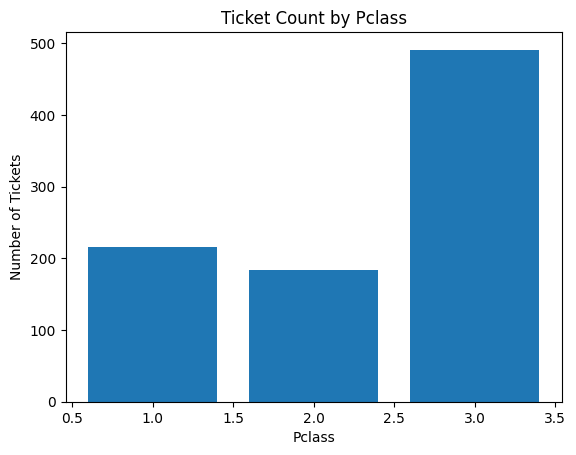

In [19]:
# SENİN KODUN BURAYA
plt.bar(pclass_df["Pclass"], pclass_df["ticket_count"])
plt.xlabel("Pclass")
plt.ylabel("Number of Tickets")
plt.title("Ticket Count by Pclass")

plt.show()

Şimdi hayatta kalanlara **survivors** bakalım.

❓ Her yolcu sınıfının hayatta kalma oranını  *survival rate* gösteren bir bar chart plot et.
`0` ,  o sınıfta kimsenin hayatta kalmadığı, `1` ise herkesin hayatta kaldığı anlamına gelir. 

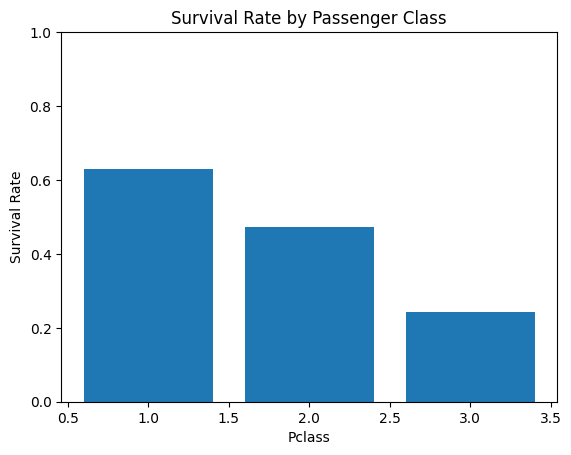

In [20]:
# SENİN KODUN BURAYA
pclass_survival = data.groupby("Pclass")["Survived"].mean().reset_index()
pclass_survival.columns = ["Pclass", "survival_rate"]

plt.bar(pclass_survival["Pclass"], pclass_survival["survival_rate"])

plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")

plt.ylim(0, 1)  # oran olduğu için 0-1 arası

plt.show()

### Gender Analysis

`Sex`  sütununa bir göz atalım.

❓ Bu sütunda kullanılan farklı değerleri kontrol etmek için [`pandas.Series.unique`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html) fonksiyonunu kullan.

In [21]:
# SENİN KODUN BURAYA
unique_cities = data['Sex'].unique()
print(unique_cities)

['male' 'female']


❓ Her cinsiyetin hayatta kalma oranını *survival rate*  gösteren bir bar chart plot et.
Verilere göre, hangi cinsiyetin hayatta kalma ihtimali daha yüksekti?

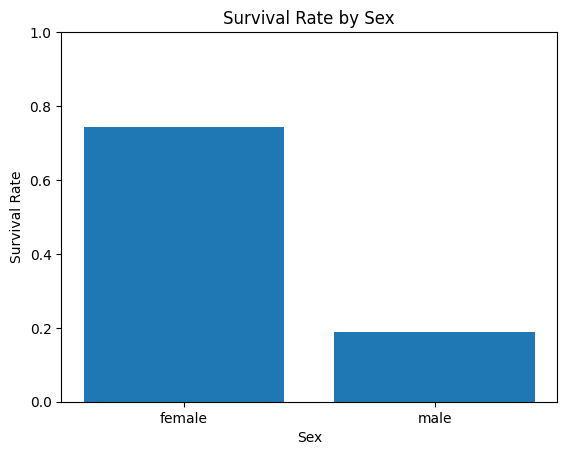

In [22]:
# SENİN KODUN BURAYA
sex_survival = data.groupby("Sex")["Survived"].mean().reset_index()
sex_survival.columns = ["sex", "survival_rate"]

plt.bar(sex_survival["sex"], sex_survival["survival_rate"])

plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")

plt.ylim(0, 1)  # oran olduğu için 0-1 arası

plt.show()


Her cinsiyet için toplam yolcu sayısını ve toplam hayatta kalan sayısını birlikte gösterdiğimiz daha şık bir histogram oluşturalım.

❓`Total` ve `Survived`  olmak üzere iki sütunlu, `male` and `female` şeklinde iki satırlı bir `survivors_df` DataFrame oluştur ve plot et.

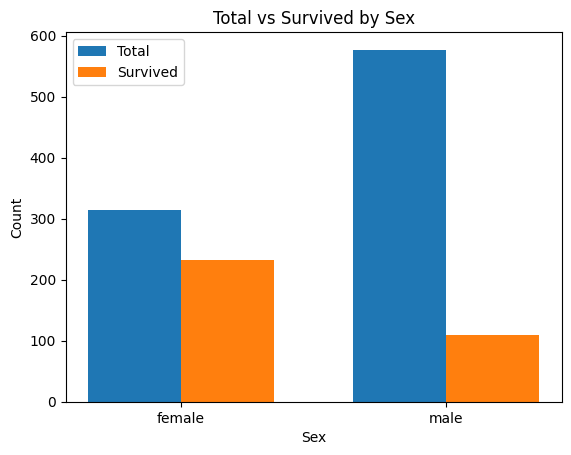

In [23]:
# SENİN KODUN BURAYA
survivors_df = data.groupby("Sex").agg(
    Total=("Survived", "count"),
    Survived=("Survived", "sum")
).reset_index()

x = np.arange(len(survivors_df["Sex"]))  # male/female index
width = 0.35

plt.bar(x - width/2, survivors_df["Total"], width, label="Total")
plt.bar(x + width/2, survivors_df["Survived"], width, label="Survived")

plt.xticks(x, survivors_df["Sex"])

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Total vs Survived by Sex")

plt.legend()
plt.show()

In [28]:
len(survivors_df['Sex'])

2

## Children

Önceki analiz yaşları dikkate almıyordu. Bir çocuğu bir yetişkinden ayırmak ve bunun hayatta kalma oranlarını *survival rates* nasıl etkilediğini görmek istiyoruz.

❓ Boolean indexing kullanarak yalnızca çocuk yolcuların satırlarını içeren bir `children_df` oluştur.

In [32]:
# SENİN KODUN BURAYA
children_df = data[data["Age"] < 18].dropna(subset=["Age"])
children_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,Q
...,...,...,...,...,...,...,...,...,...,...,...
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,S
852,853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,C
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,S


❓ Titanic’te kaç çocuk vardı?

In [33]:
# SENİN KODUN BURAYA
children_df.shape

(113, 11)

❓Kaç çocuk hayatta kaldı?

In [35]:
# SENİN KODUN BURAYA
children_df_lived = children_df[children_df["Survived"] == 1]
children_df_lived.shape

(61, 11)

❓ Her kategori için( `male`, `female`, `children`).hayatta kalanlar / toplam oranını gösteren bir bar chart plot et. Unutma: `male` istatistiklerinden erkek çocukları, `female` istatistiklerinden ise kız çocukları çıkarman **substract** gerekiyor.

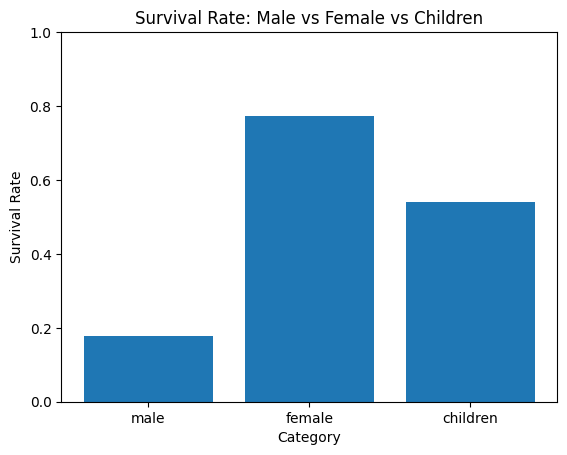

In [36]:
# SENİN KODUN BURAYA

adult_df = data[data["Age"] >= 18].dropna(subset=["Age"])

male_df = adult_df[adult_df["Sex"] == "male"]
female_df = adult_df[adult_df["Sex"] == "female"]

male_rate = male_df["Survived"].mean()
female_rate = female_df["Survived"].mean()
children_rate = children_df["Survived"].mean()

survival_df = pd.DataFrame({
    "category": ["male", "female", "children"],
    "survival_rate": [male_rate, female_rate, children_rate]
})

plt.bar(survival_df["category"], survival_df["survival_rate"])

plt.xlabel("Category")
plt.ylabel("Survival Rate")
plt.title("Survival Rate: Male vs Female vs Children")

plt.ylim(0, 1)

plt.show()

## [Opsiyonal] Big families

❓ Daha büyük ailelerin hayatta kalması daha mı zordu?

Burada, yolcunun aile büyüklüğünü gösteren yeni bir sütunu `DataFrame` ine ekleyeceksin.
  

In [38]:
# SENİN KODUN BURAYA
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
data["IsAlone"] = data["FamilySize"] == 1

## [Opsiyonal] Distinguished titles

❓ Tahliye sırasında ünvanı (Mr, Mrs, Dr vb.) olan yolculara daha fazla öncelik verildi mi?

Bunu incelemek için, bazı string manipülasyonları yaparak her yolcu için ünvanını içeren yeni bir sütun oluştur.

In [ ]:
# SENİN KODUN BURAYA
data["Title"] = data["Name"].str.extract(r",\s*([^\.]+)\.")
title_survival = data.groupby("Title")["Survived"].mean().reset_index()
title_survival.columns = ["Title", "survival_rate"]

#subset = title_survival[title_survival["Title"].isin(["Capt", "Col", "Sir"])]

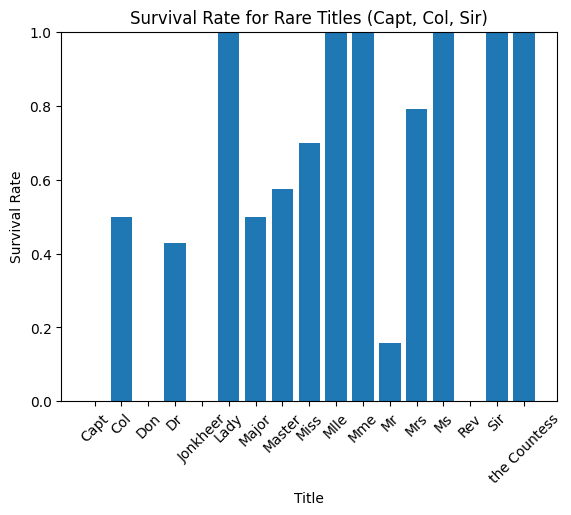

In [44]:
plt.bar(title_survival["Title"], title_survival["survival_rate"])
plt.xticks(rotation=45)

plt.xlabel("Title")
plt.ylabel("Survival Rate")
plt.title("Survival Rate for Rare Titles (Capt, Col, Sir)")

plt.ylim(0, 1)

plt.show()